<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%B0%D0%BC%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [ ]:
import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
url = 'https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw06_texts/tweets_coronavirus.csv'
data = pd.read_csv(url)
data.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃT: 36.319708,-82.363649",16-03-2020,As news of the regionÂs first confirmed COVID...,Positive
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,Positive
6,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,Positive
7,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",Negative
8,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",Extremely Positive
9,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÂs ALL ...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [ ]:
mapping = {
    "Positive": 1,
    "Extremely Positive": 1,
    "Negative": 0,
    "Extremely Negative": 0
}
data["Sentiment"] = data["Sentiment"].map(mapping)

In [ ]:
data["Sentiment"].unique()

array([1, 0])

In [ ]:
data.iloc[9023]['OriginalTweet']

"Shop keepers taking advantage of #Coronavirus boosting prices disproportionately so the most Marginalised suffer who can't afford it #SHAMEONYOU #Wewillremember"

Сбалансированы ли классы?

In [ ]:
class_count = data["Sentiment"].value_counts()
class_ratio = class_count / len(data)
class_ratio

,count
Sentiment,
1,0.539589
0,0.460411


**Ответ:** можно скачать, что, в целом, классы сбалансированы (с небольшой погрешностью, но незначительной)

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [ ]:
missing_values = data.isnull().sum()
missing_values

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [ ]:
data = data.apply(lambda x: x.fillna('Unknown'))

In [ ]:
missing_values = data.isnull().sum()
missing_values

,0
UserName,0
ScreenName,0
Location,0
TweetAt,0
OriginalTweet,0
Sentiment,0


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data,
                              test_size=0.3,
                              random_state=0)



---



## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
nltk.download("punkt_tab", quiet=True)

True

In [ ]:
from collections import Counter
all_tokens = []

for tweet in train["OriginalTweet"]:
    tokens = word_tokenize(tweet.lower())
    all_tokens.extend(tokens)

tokens_count = Counter(all_tokens)
tokens_count = dict(Counter(all_tokens))

Какой размер словаря получился?

In [ ]:
len(tokens_count)

57290

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [ ]:
sorted_tokens = sorted(tokens_count.items(), key=lambda item: item[1], reverse=True)
print(sorted_tokens[:10])

[('#', 42753), ('the', 26928), ('to', 23466), ('.', 22737), (',', 17556), (':', 16478), ('and', 14792), ('of', 13043), ('https', 12921), ('a', 11833)]


**Ответ:** в топе находятся стоп-слова, которые создают шум и не несут в себе информации, пригодившейся для анализа тектов. Такие слова нужно удалять.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [ ]:
import nltk
from nltk.corpus import stopwords
from string import punctuation

nltk.download("stopwords", quiet=True)
noise = stopwords.words("english") + list(punctuation)

filtered_tokens_count = {token: x for token, x in tokens_count.items() if token not in noise}
sorted_tokens = sorted(filtered_tokens_count.items(), key=lambda item: item[1], reverse=True)

In [ ]:
print(sorted_tokens[:10])

[('https', 12921), ('coronavirus', 9965), ('prices', 4618), ('covid-19', 4550), ('food', 4490), ('supermarket', 3990), ('store', 3874), ('grocery', 3584), ('people', 3489), ('amp', 3342)]


**Ответ:**  среди популярных токенов встречаются два о коронавирусе, остальные - распространенные в повседневной реши слова (кроме "https"). Видно, что в твиттах много ссылок (и, скорее всего, их "хвосты" находятся на дне по популярности и не несут никакого аналитического смысла).

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [ ]:
print(sorted_tokens[-20:])

[('//t.co/lw1r0rm7xs', 1), ('//t.co/5cbliqzx7l', 1), ('now.when', 1), ('milion', 1), ('skellig', 1), ('skelligsix18', 1), ('skelligcoast2kms', 1), ('southkerry', 1), ('//t.co/zjcl195vqs', 1), ('srinivasiyc', 1), ('//t.co/iaek4fwsgz', 1), ('premiership', 1), ('non-playing', 1), ('subsidise', 1), ('playersâ\x92', 1), ('renewing', 1), ('flew', 1), ('torontopearson', 1), ('680news', 1), ('//t.co/7j2y3rsld9', 1)]


**Ответ:** если рассуждать логически, токены, которые встречаются реже всего не повлияют на анализ текстов. Конечно, обрезки ссылок могут зашумлять выборку, но с этим можно мириться. Тем более, помимо ссылок в числе наименее упомянутых находятся и слова, несущие смысл. Принято решение не работать с этими словами дополнительно.


---





Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [ ]:
from nltk.tokenize import TweetTokenizer

tw = TweetTokenizer()
all_tokens = []

for tweet in train["OriginalTweet"]:
    tokens = tw.tokenize(tweet.lower())
    all_tokens.extend(tokens)

tokens_count = Counter(all_tokens)
tokens_count = dict(Counter(all_tokens))

In [ ]:
sorted_tokens = sorted(tokens_count.items(), key=lambda item: item[1], reverse=True)
print(sorted_tokens[:10])

[('the', 26993), ('.', 24118), ('to', 23478), (',', 17571), ('and', 14825), ('of', 13044), ('a', 11891), ('in', 11348), ('?', 9524), ('#coronavirus', 8808)]


**Ответ:** отличается тем, что решетка в хeштеге не отделилась от слов

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [ ]:
from string import punctuation

nltk.download("stopwords", quiet=True)
noise = stopwords.words("english") + list(punctuation)

filtered_tokens_count = {token: x for token, x in tokens_count.items() if token not in noise}
sorted_tokens = sorted(filtered_tokens_count.items(), key=lambda item: item[1], reverse=True)

print(sorted_tokens[:10])

[('#coronavirus', 8808), ('19', 7167), ('covid', 6253), ('prices', 4601), ('\x92', 4372), ('food', 4367), ('store', 3877), ('supermarket', 3805), ('grocery', 3523), ('people', 3463)]


**Ответ:** видно кусок ссылки, хэштеги, которые не отделены от решетки, в прошлый раз такого не было.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [ ]:
filtered_tokens_count = {}

filtered_tokens_count = {token: count for token, count in tokens_count.items()
                         if len(token) > 1 and all(ord(char) < 128 for char in token)}

sorted_tokens = sorted(filtered_tokens_count.items(), key=lambda item: item[1], reverse=True)

In [ ]:
print(sorted_tokens[:10])

[('the', 26993), ('to', 23478), ('and', 14825), ('of', 13044), ('in', 11348), ('#coronavirus', 8808), ('for', 8625), ('is', 7464), ('19', 7167), ('are', 7124)]


In [ ]:
print(sorted_tokens[-20:])

[('https://t.co/pd6ual9yfi', 1), ('https://t.co/lw1r0rm7xs', 1), ('https://t.co/5cbliqzx7l', 1), ('now.when', 1), ('milion', 1), ('skellig', 1), ('@skelligsix18', 1), ('#skelligcoast2kms', 1), ('#southkerry', 1), ('https://t.co/zjcl195vqs', 1), ('@srinivasiyc', 1), ('https://t.co/iaek4fwsgz', 1), ('premiership', 1), ('non-playing', 1), ('subsidise', 1), ('renewing', 1), ('flew', 1), ('@torontopearson', 1), ('@680news', 1), ('https://t.co/7j2y3rsld9', 1)]


**Ответ:** ссылки стали неделимыи (это лучше), меньше зашумления выборки. Хештеги неотделимы с решетками, что в будущем будет мешать при обработке данных (это хуже).

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [ ]:
hashtag_tokens = [(x, amount) for x, amount in sorted_tokens if x.startswith("#")]
print(hashtag_tokens[:10])

[('#coronavirus', 8808), ('#covid19', 2589), ('#covid_19', 1734), ('#covid2019', 946), ('#toiletpaper', 744), ('#covid', 641), ('#socialdistancing', 465), ('#coronacrisis', 448), ('#pandemic', 257), ('#coronaviruspandemic', 249)]


**Ответ:** все хештеги связаны с коронавирусом, среди них очень много повторяющихся по значению ("#coronavirus", "#covid19", "#covid_19" и тд).

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [ ]:
hashtag_tokens = [(x, amount) for x, amount in sorted_tokens if x.startswith("https://t.co")]
print(hashtag_tokens[:10])

[('https://t.co/oxa7swtond', 5), ('https://t.co/gp3eusapl8', 4), ('https://t.co/wrlhyzizaa', 3), ('https://t.co/kuwipf1kqw', 3), ('https://t.co/zjnrx6dkkn', 3), ('https://t.co/3gbbdpdjat', 3), ('https://t.co/e2znxajpre', 3), ('https://t.co/catkegayoy', 3), ('https://t.co/g63rp042ho', 3), ('https://t.co/aziqcdgrnn', 3)]


**Ответ:** ссылки встречаются в малых количествах и не несут особой пользы для оценки эмоциональной окраски твита.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [ ]:
def custom_tokenizer(text):
  lower_case_text = text.lower()
  tweet_tokenizer = TweetTokenizer()
  stop_words = set(stopwords.words("english")) | set(punctuation)

  tokens_before = tweet_tokenizer.tokenize(lower_case_text)

  tokens = [
        token for token in tokens_before
        if len(token) > 1
           and all(ord(c) < 128 for c in token)
           and token.lower() not in stop_words
           and not token.startswith("https://t.co")
    ]

  return tokens

In [ ]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
X = cv.fit_transform(train["OriginalTweet"])

print(len(cv.vocabulary_))

44086


**Ответ:** уменьшился более чем на 10 тысяч, что объянимо удалением ссылок, дополнительных стоп-слов и токенов из одного символа.

Посмотрим на какой-нибудь конкретный твитт:

In [ ]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [ ]:
tweet_text = train.iloc[ind]['OriginalTweet']

In [ ]:
vector = cv.transform([tweet_text]).toarray()[0]
feature_names = cv.get_feature_names_out()
not_zero_values = vector.nonzero()[0]

main_token = feature_names[not_zero_values[np.argmax(vector[not_zero_values])]]
last_token = feature_names[not_zero_values[np.argmin(vector[not_zero_values])]]

In [ ]:
print(f"Важный: {main_token}. Неважный: {last_token}")

Важный: #coronavirusoutbreak. Неважный: #coronavirusoutbreak


**Ответ:** CountVectorizer посчитывает для каждого текста количество вхождений уникальных токенов в него. В данном случае наш текст не содержит одинаковых слов, поэтому CountVectorizer составит вектор, состоящий из нулей и единиц (единица будет у тех слов, которые содержатся в нашем твите, то есть все слова будут иметь по единице). Судя по всему, токену #coronavirusoutbreak соответуствет первая единица в векторе для нашего текста, поэтому его выводят и в качестве самого важного, и в качестве самого неважного токена.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer)
X_tfidf = tfidf_vec.fit_transform(train["OriginalTweet"])

vector = tfidf_vec.transform([tweet_text]).toarray()[0]
feature_names = tfidf_vec.get_feature_names_out()
not_zero_values = vector.nonzero()[0]

main_token = feature_names[not_zero_values[np.argmax(vector[not_zero_values])]]
last_token = feature_names[not_zero_values[np.argmin(vector[not_zero_values])]]

print(f"Важный: {main_token}. Неважный: {last_token}")

Важный: brainless. Неважный: food


**Ответ:** тут уже более грамотный подход к векторизации. Мера TF-IDF оценивает твитт с двух сторон: с позиции самого твитта (для каждого слова считается количество вхождений в текст и делится на общее кол-во слов в тексте), а потом оценивается важность слова по отношению ко всем текстам выборки (чем чаще слово встречается, тем меншье у него будет вес). Такое разделение помогает найти действительно важные для оценки текстов токены, отсеиваю частоупотребляемые слова.

В нашем случае слово brainless достаточно редковстречаемое и несет некую эмоциональную негативную окраску (можно сделать вывод, что самое важное слово обнаружено корректно), а слово food является общеупотребительным и какую-либо эмоционалную окраску не несет. Таким образом, векторизация в данном случае работает корректно.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [ ]:
positive = train[train['OriginalTweet'].apply(lambda x: 'amazing' in x) & (train['Sentiment'] == 1)]

In [ ]:
positive.iloc[43]['OriginalTweet'], positive.iloc[4]['Sentiment']

('Rather than buying (and hoarding) that extra 24 pack of toilet paper, do this instead! Please give what you can to this amazing initiative, helping the most vulnerable. #coronavirus #BeKind #StopHoarding https://t.co/lPy7ekH8gx',
 np.int64(1))

In [ ]:
positive_tweet = positive.iloc[43]['OriginalTweet']

In [ ]:
vector = tfidf_vec.transform([positive_tweet]).toarray()[0]
feature_names = tfidf_vec.get_feature_names_out()
not_zero_values = vector.nonzero()[0]

main_token = feature_names[not_zero_values[np.argmax(vector[not_zero_values])]]
last_token = feature_names[not_zero_values[np.argmin(vector[not_zero_values])]]

print(f"Важный: {main_token}. Неважный: {last_token}")

Важный: initiative. Неважный: #coronavirus


**Ответ:** слово инициатива не употребляется в негативном ключе (как правило), поэтому векторайзер хорошо определил важный токен. Слово встречается один раз в тексте, при этом достаточно редкоупотребляемое (поэтому у него должен быть высокий IDF). Также почти все слова тваатта частоупотребляемые, что снижает их важность.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [ ]:
y_train = train['Sentiment']
y_test = test['Sentiment']
x_train = train.drop(columns=['Sentiment'])
x_test = test.drop(columns=['Sentiment'])

count_vectorizer = CountVectorizer(tokenizer=custom_tokenizer)
X_train_count = count_vectorizer.fit_transform(x_train['OriginalTweet'])
X_test_count = count_vectorizer.transform(x_test['OriginalTweet'])

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer)
X_train_tfidf = tfidf_vectorizer.fit_transform(x_train['OriginalTweet'])
X_test_tfidf = tfidf_vectorizer.transform(x_test['OriginalTweet'])

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
logreg_count = LogisticRegression(max_iter=1000)
logreg_count.fit(X_train_count, y_train)

y_pred_train_count = logreg_count.predict(X_train_count)
accuracy_train_count = accuracy_score(y_train, y_pred_train_count)

y_pred_test_count = logreg_count.predict(X_test_count)
accuracy_test_count = accuracy_score(y_test, y_pred_test_count)

print(f"Точность на обучении (CountVectorizer): {accuracy_train_count:.4f}")
print(f"Точность на тестировании (CountVectorizer): {accuracy_test_count:.4f}")

Точность на обучении (CountVectorizer): 0.9840
Точность на тестировании (CountVectorizer): 0.8658


In [ ]:
logreg_tfidf = LogisticRegression(max_iter=1000)
logreg_tfidf.fit(X_train_tfidf, y_train)

y_pred_train_tfidf = logreg_tfidf.predict(X_train_tfidf)
accuracy_train_tfidf = accuracy_score(y_train, y_pred_train_tfidf)

y_pred_test_tfidf = logreg_tfidf.predict(X_test_tfidf)
accuracy_test_tfidf = accuracy_score(y_test, y_pred_test_tfidf)

print(f"Точность на обучении (TF-IDF): {accuracy_train_tfidf:.4f}")
print(f"Точность на тестировании (TF-IDF): {accuracy_test_tfidf:.4f}")

Точность на обучении (TF-IDF): 0.9235
Точность на тестировании (TF-IDF): 0.8533


**Ответ:** у модели CountVectorizer наблюдаются признаки переобучения. TF-IDF в этом плане более утойчив (меньше разница в accuracy на train и test). Странно, что CountVectorizer показал лучший результат и обошел (хоть и слегка) TF-IDF. Разница между ними невелика и, скорее всего, лучше все-таки использовать TF-IDF, так как он гарантирует большую надежность.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [ ]:
from nltk.stem.snowball import SnowballStemmer

In [ ]:
def custom_stem_tokenizer(text):
  stemmer = SnowballStemmer("english")

  lower_case_text = text.lower()

  tweet_tokenizer = TweetTokenizer()
  stop_words = set(stopwords.words("english")) | set(punctuation)

  tokens_before = tweet_tokenizer.tokenize(lower_case_text)

  tokens = [
        token for token in tokens_before
        if len(token) > 1
           and all(ord(c) < 128 for c in token)
           and token.lower() not in stop_words
           and not token.startswith("https://t.co")
    ]

  text_stemmed = [stemmer.stem(w) for w in tokens]

  return text_stemmed

In [ ]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [ ]:
count_vectorizer = CountVectorizer(tokenizer=custom_stem_tokenizer)
X_train_count = count_vectorizer.fit_transform(x_train['OriginalTweet'])
X_test_count = count_vectorizer.transform(x_test['OriginalTweet'])

print(len(count_vectorizer.vocabulary_))

35433


In [ ]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X_train_tfidf = tfidf_vectorizer.fit_transform(x_train['OriginalTweet'])
X_test_tfidf = tfidf_vectorizer.transform(x_test['OriginalTweet'])

print(len(tfidf_vectorizer.vocabulary_))

35433


**Ответ** логично, что размер словаря уменьшится, так как при применении стемминга у слов отбрасываются аффиксы (например слова "criticism" и "criticize", которые ранее были разными словами, после стемминга станут одним токеном "critic").

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [ ]:
logreg_count = LogisticRegression(max_iter=1000)
logreg_count.fit(X_train_count, y_train)

y_pred_train_count = logreg_count.predict(X_train_count)
accuracy_train_count = accuracy_score(y_train, y_pred_train_count)

y_pred_test_count = logreg_count.predict(X_test_count)
accuracy_test_count = accuracy_score(y_test, y_pred_test_count)

print(f"Точность на обучении (CountVectorizer): {accuracy_train_count:.4f}")
print(f"Точность на тестировании (CountVectorizer): {accuracy_test_count:.4f}")

Точность на обучении (CountVectorizer): 0.9706
Точность на тестировании (CountVectorizer): 0.8665


In [ ]:
logreg_tfidf = LogisticRegression(max_iter=1000)
logreg_tfidf.fit(X_train_tfidf, y_train)

y_pred_train_tfidf = logreg_tfidf.predict(X_train_tfidf)
accuracy_train_tfidf = accuracy_score(y_train, y_pred_train_tfidf)

y_pred_test_tfidf = logreg_tfidf.predict(X_test_tfidf)
accuracy_test_tfidf = accuracy_score(y_test, y_pred_test_tfidf)

print(f"Точность на обучении (TF-IDF): {accuracy_train_tfidf:.4f}")
print(f"Точность на тестировании (TF-IDF): {accuracy_test_tfidf:.4f}")

Точность на обучении (TF-IDF): 0.9136
Точность на тестировании (TF-IDF): 0.8573


**Ответ:** точность на тесте слегка повысилась для обеих моделей. В данном случае стемминг себя хорошо показал, но его положительное влияние сильно зависит от конкретной задачи. Для каждого случая все индивидуально, поэтому нельзя сказать, что его необходимо использовать всегда.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.35).fit(x_train['OriginalTweet'])
print(len(cv_df.vocabulary_))

35432


In [ ]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_stem_tokenizer,
                                   max_df=0.35).fit(x_train['OriginalTweet'])

print(len(tfidf_vectorizer.vocabulary_))

35432


**Ответ:** max_df позволяет отсеивать наиболее распространенные в текстах выборки токены. В данном случае отсеиваются все токены, которые встречаются более чем в 35% текстах. Такое пороговое значение уменьшило размер словаря ровно на один признак.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11).fit(x_train['OriginalTweet'])
print(len(cv_df.vocabulary_))

3616


In [ ]:
count_vectorizer = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=11)
X_train_count = count_vectorizer.fit_transform(x_train['OriginalTweet'])
X_test_count = count_vectorizer.transform(x_test['OriginalTweet'])

In [ ]:
logreg_count = LogisticRegression(max_iter=1000)
logreg_count.fit(X_train_count, y_train)

y_pred_train_count = logreg_count.predict(X_train_count)
accuracy_train_count = accuracy_score(y_train, y_pred_train_count)

y_pred_test_count = logreg_count.predict(X_test_count)
accuracy_test_count = accuracy_score(y_test, y_pred_test_count)

print(f"Точность на обучении (CountVectorizer): {accuracy_train_count:.4f}")
print(f"Точность на тестировании (CountVectorizer): {accuracy_test_count:.4f}")

Точность на обучении (CountVectorizer): 0.9281
Точность на тестировании (CountVectorizer): 0.8669


**Ответ:** хорошие результаты, уменьшилось переобучение модели (разница качества прогнозов на train и test упала). Такой эффект достигается благодаря уменьшению словаря, то есть количества признаков. Следовательно, модель становится более простой.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_count)
X_test_scaled = scaler.transform(X_test_count)

logreg_scaled = LogisticRegression(max_iter=1000)
logreg_scaled.fit(X_train_scaled, y_train)

y_pred_train_scaled = logreg_scaled.predict(X_train_scaled)
accuracy_train_scaled = accuracy_score(y_train, y_pred_train_scaled)

y_pred_test_scaled = logreg_scaled.predict(X_test_scaled)
accuracy_test_scaled = accuracy_score(y_test, y_pred_test_scaled)

print(f"Точность на обучении: {accuracy_train_scaled:.4f}")
print(f"Точность на тестировании: {accuracy_test_scaled:.4f}")

Точность на обучении: 0.9396
Точность на тестировании: 0.8464


In [ ]:
feature_names = count_vectorizer.get_feature_names_out()
coefficients = logreg_scaled.coef_[0]
top_positive_tokens = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]
top_negative_tokens = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

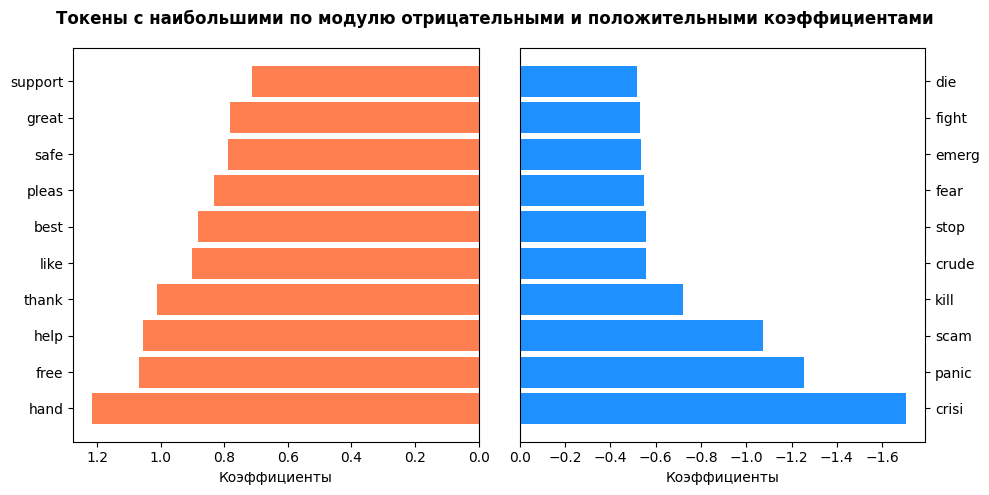

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.barh(
    y = [token for token, _ in top_positive_tokens],
    width = [coef for _, coef in top_positive_tokens],
    height = 0.85,
    color='Coral',
)

ax2.barh(
    y = [token for token, _ in top_negative_tokens],
    width = [coef for _, coef in top_negative_tokens],
    height=0.85,
    color='DodgerBlue',
)

ax1.set_xlabel('Коэффициенты')

ax2.set_xlabel('Коэффициенты')
ax1.invert_xaxis()
ax2.invert_xaxis()
ax2.yaxis.tick_right()

fig.suptitle('Токены с наибольшими по модулю отрицательными и положительными коэффициентами', fontweight='bold')

plt.tight_layout()
plt.show()

**Ответ:** токены, обладающие набольшими положительными коэффициентами имеют яркую положительную окраску ("support", "best" и т.д). Токены, обладающие наибольшими по модулю отрицательными значениями, обладают резко негативным значением ("kill", "panic" и т.д.)

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
x_train["ScreenName"].size

23410

In [ ]:
x_train["ScreenName"].unique().size

23410

In [ ]:
x_train["UserName"].unique().size

23410

**Ответ:** признаки не важны, это уникальные идентификаторы пользователей, которые не принесут пользы при прогнозировании.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
import math

In [ ]:
x_train['TweetAt'] = pd.to_datetime(x_train['TweetAt'], format='%d-%m-%Y')
x_test['TweetAt'] = pd.to_datetime(x_test['TweetAt'], format='%d-%m-%Y')

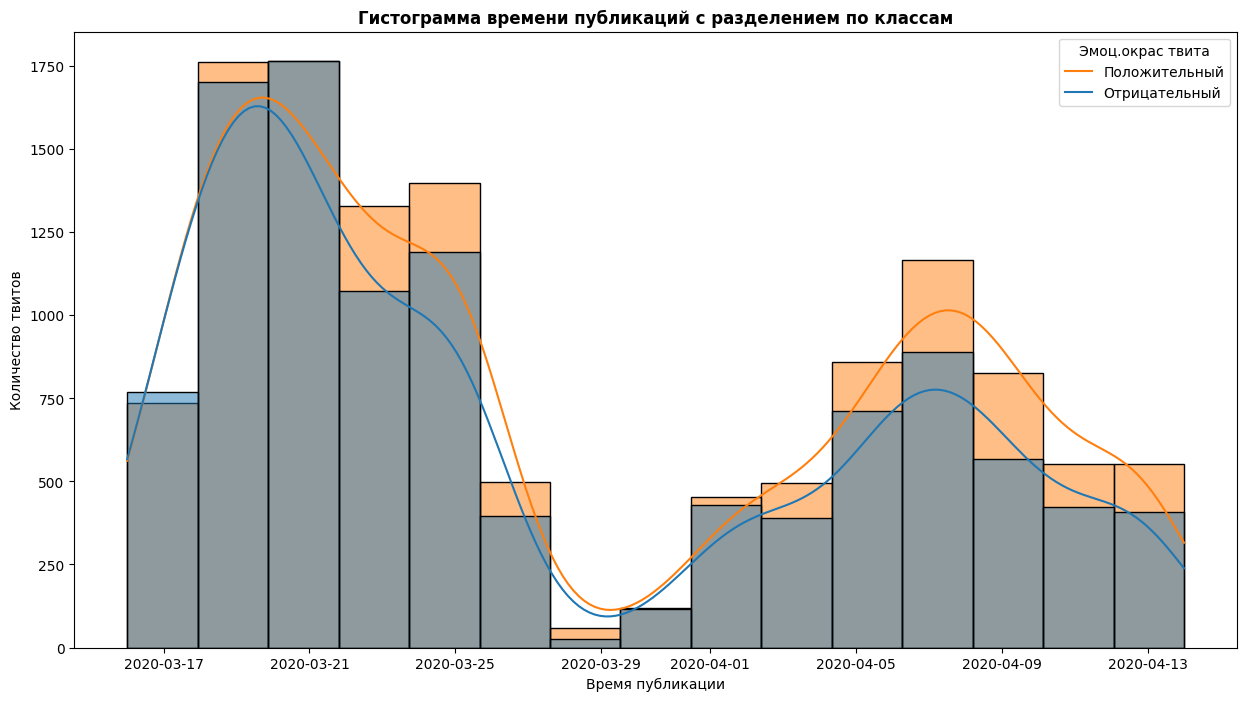

In [ ]:
ster = 1 + math.floor(3.32 * math.log10(x_train['TweetAt'].size)) # тут по формуле Стерджерса считаю bins чтобы график был не дырявый

plt.figure(figsize=(15, 8))
sns.histplot(data=x_train, x='TweetAt', hue=y_train, bins=ster, kde=True)
plt.title('Гистограмма времени публикаций с разделением по классам', fontweight='bold')
plt.xlabel('Время публикации')
plt.ylabel('Количество твитов')
plt.legend(title='Эмоц.окрас твита', labels=["Положительный", "Отрицательный"])
plt.show()

**Ответ:** распределения негативных и положительных твитов практически совпадают. Если бы наблюдались четкие различия в датах публикаций твитов с разной эмоциональной окраской, то признак был бы полезен. В данном случае необходимость его добавления отсутствует.



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [ ]:
print(f"Кол-во уникальных значений Locatiion: {x_train['Location'].nunique()}")

Кол-во уникальных значений Locatiion: 7949


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [ ]:
top_locations = x_train[x_train['Location'] != 'Unknown']['Location'].value_counts().head(10)

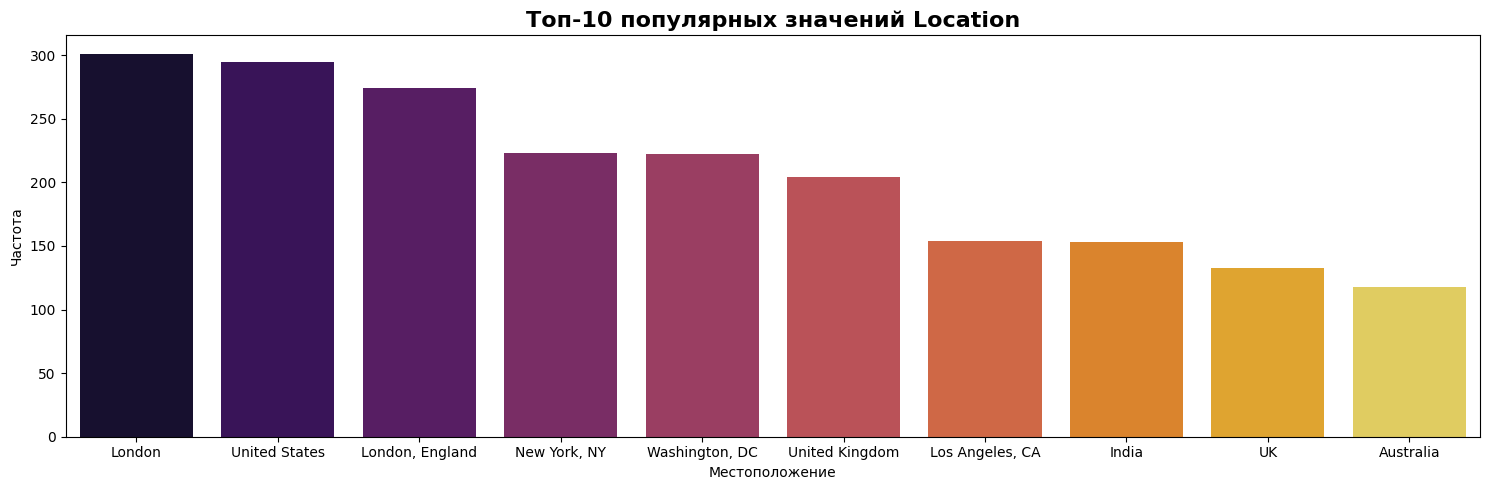

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x=top_locations.index, y=top_locations.values, palette="inferno")
plt.title('Топ-10 популярных значений Location', fontsize=16, fontweight='bold')
plt.xlabel('Местоположение')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [ ]:
x_train['WiderLocation'] = x_train['Location'].apply(lambda x: x.split(', ')[-1].strip())
x_test['WiderLocation'] = x_test['Location'].apply(lambda x: x.split(', ')[-1].strip())

x_train.drop(columns=['Location'])
x_test.drop(columns=['Location'])

,UserName,ScreenName,TweetAt,OriginalTweet,WiderLocation
28168,38343,83295,2020-04-08,What will the post-COVID-19 consumer look like...,London
19874,28015,72967,2020-03-26,It's crazy how going to the grocery store is s...,MD
31702,42798,87750,2020-04-12,Best online stores to buy things from Tokyo an...,Japan
5110,10012,54964,2020-03-19,#AngelaMerkel Nails #Coronavirus Speech Â Unl...,Ohio
30081,40750,85702,2020-04-10,Just saw someone at the grocery store lick the...,MI
...,...,...,...,...,...
5847,10903,55855,2020-03-19,As a supermarket assistant went through my bas...,Yorkshire Â UK Â Europe
3220,7693,52645,2020-03-18,#NewsAlert | The benchmark West Texas Intermed...,India
11637,17912,62864,2020-03-21,ItÂs starting. Sh*tÂs getting weird.\r\r\n\r...,Lexington/Phoenix
21149,29590,74542,2020-04-01,@henrymcmaster I work in a definitely nonessen...,Unknown


In [ ]:
print(f"Кол-во уникальных значений WiderLocation: {x_train['WiderLocation'].nunique()}")

Кол-во уникальных значений WiderLocation: 4723


In [ ]:
top_locations = x_train[x_train['WiderLocation'] != 'Unknown']['WiderLocation'].value_counts().head(10)

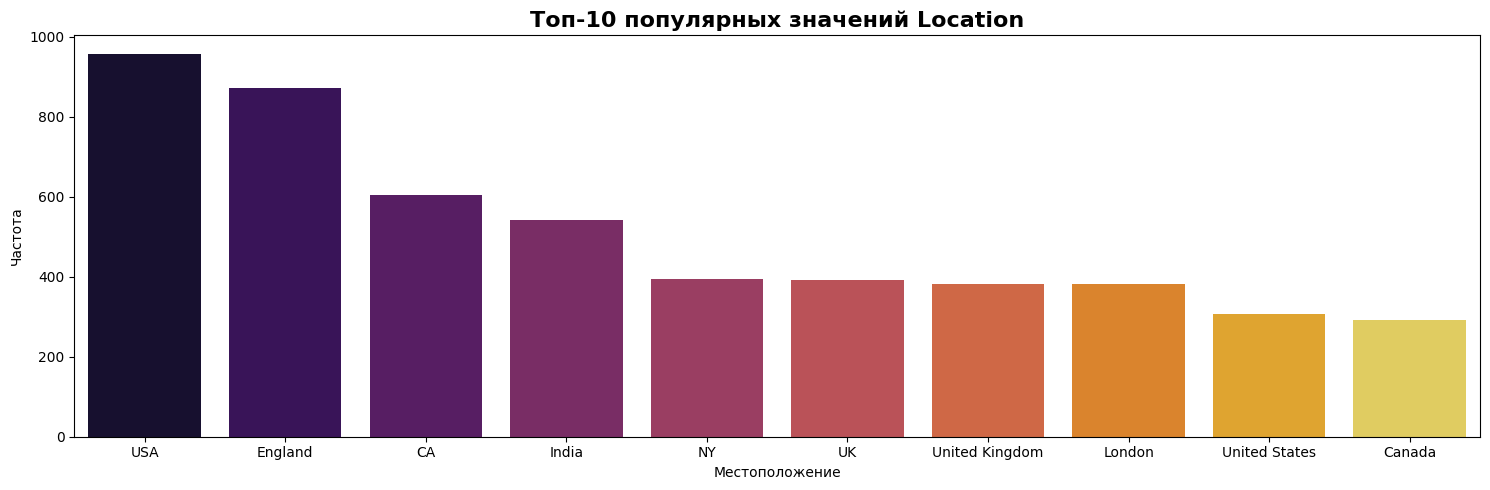

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x=top_locations.index, y=top_locations.values, palette="inferno")
plt.title('Топ-10 популярных значений Location', fontsize=16, fontweight='bold')
plt.xlabel('Местоположение')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
locations_to_encode = x_train['WiderLocation'].value_counts().loc[lambda x: x > 1].index.tolist()

ohe_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
    categories=[locations_to_encode]
)

column_trans = ColumnTransformer(
    [('encoder', ohe_encoder, ['WiderLocation'])],
    remainder='drop'
)

column_trans.fit(x_train[['WiderLocation']])

WiderLocation_train_ohe = column_trans.transform(x_train[['WiderLocation']])
WiderLocation_test_ohe = column_trans.transform(x_test[['WiderLocation']])

In [ ]:
print(f"Количество значений местоположений, котрые встречаются больше одного раза: {len(locations_to_encode)}")

Количество значений местоположений, котрые встречаются больше одного раза: 987


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
from sklearn.metrics import classification_report
import scipy.sparse as sp

In [ ]:
X_train_combined = sp.hstack([X_train_scaled, WiderLocation_train_ohe])
X_test_combined = sp.hstack([X_test_scaled, WiderLocation_test_ohe])

In [ ]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_combined, y_train)

y_pred = clf.predict(X_test_combined)

accuracy = accuracy_score(y_test, y_pred)

print(f'Точность модели на тесте: {accuracy:.4f}')

Точность модели на тесте: 0.8473


In [ ]:
y_pred_train = clf.predict(X_train_combined)

accuracy = accuracy_score(y_train, y_pred_train)

print(f'Точность модели на трейне: {accuracy:.4f}')

Точность модели на трейне: 0.9434


**Ответ:** признак практически никак не повлиял на качество прогнозов (в сравнении с последним измерением качества в задании 6, где был использован датасет с необработанным столбцом Location). По результатм наблюдается небольшое улучшение, поэтому можно сделать вывод, что колоссальных изменений обработка этого признака не вызвала, но также она не была бесполезной.